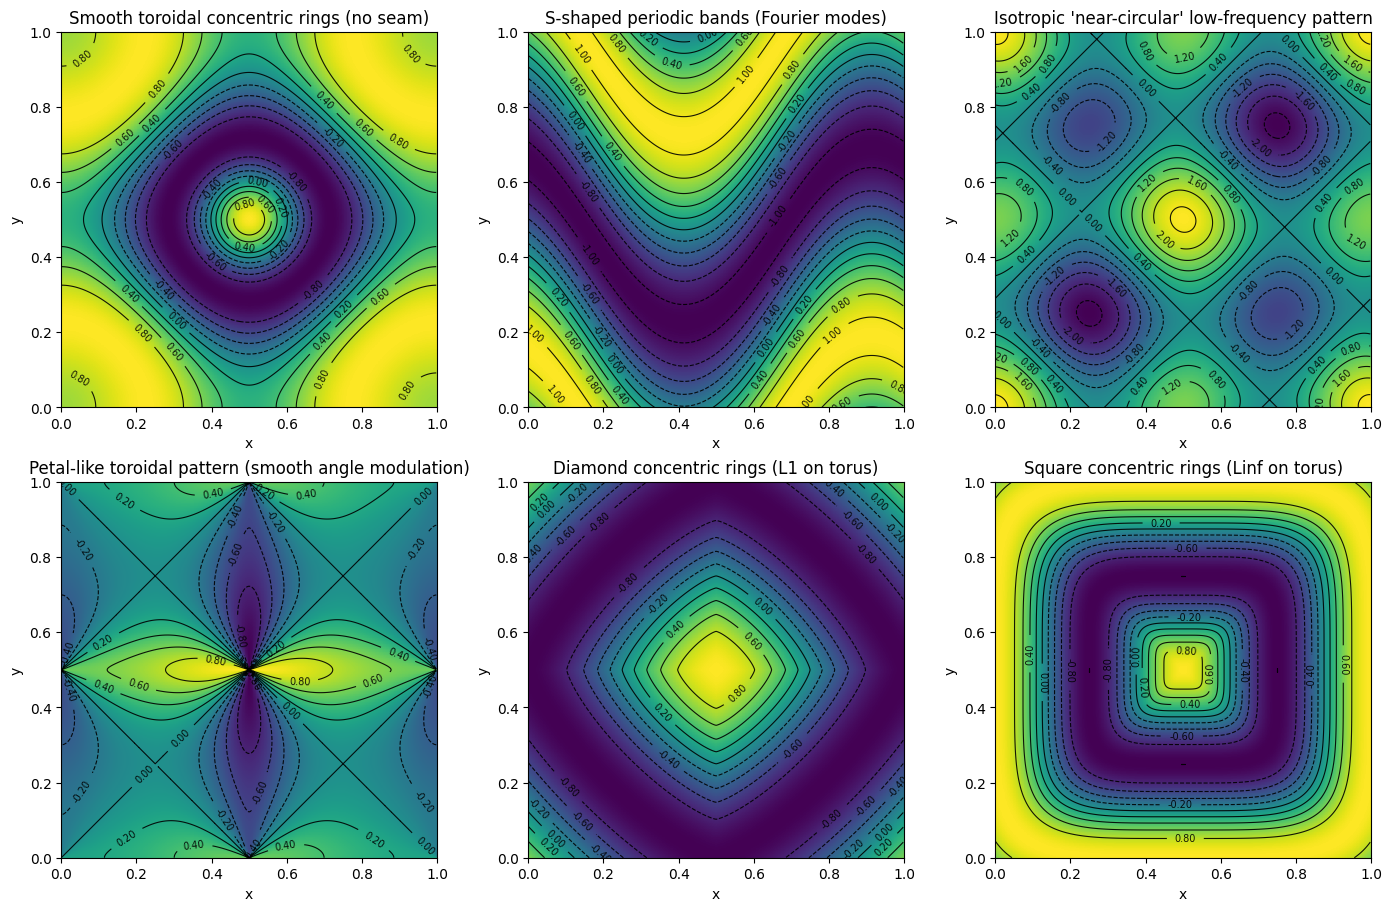

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 已有：光滑周期“半径” ----------
def r_cos(x, y, x0=0.5, y0=0.5):
    dx = 2*np.pi*(x - x0)
    dy = 2*np.pi*(y - y0)
    r2 = (2 - 2*np.cos(dx)) + (2 - 2*np.cos(dy))
    return np.sqrt(r2)

# ---------- 新增：环面 L^p 周期“半径” ----------
def _wrap01(u):
    """wrap to [-0.5, 0.5) for torus distance"""
    return u - np.round(u)

def r_torus_lp(x, y, p=np.inf, x0=0.5, y0=0.5):
    """
    Periodic L^p 'radius' on [0,1)x[0,1):
    p=1  -> diamond (L1)
    p=∞  -> square  (Linf)
    other p>=1 -> superellipse family
    """
    dx = _wrap01(x - x0)
    dy = _wrap01(y - y0)
    ax = np.abs(dx); ay = np.abs(dy)
    if np.isinf(p):
        return np.maximum(ax, ay)            # L^∞
    elif p == 1:
        return ax + ay                       # L^1
    else:
        return (ax**p + ay**p)**(1.0/p)      # L^p

# ---------- 你已有的 4 个确定性周期场 ----------
def field_concentric_rings_smooth(x, y, x0=0.33, y0=0.57, k=3.0):
    r = r_cos(x, y, x0, y0)
    return np.cos(k * r)

def field_s_bands(x, y, phi=np.pi/5, A=0.22, B=0.10):
    s = A*np.sin(2*np.pi*x) + B*(1.0 - np.cos(2*np.pi*x))
    phase = 2*np.pi*(y + s)
    return np.sin(phase) + 0.6*np.cos(phase + phi)

def field_isotropic_near_circles(x, y):
    return (np.cos(4*np.pi*x) +
            np.cos(4*np.pi*y) +
            0.5*np.cos(2*np.pi*(x + y)))

def field_petals_smooth(x, y, x0=0.68, y0=0.28, m=8, k=3.0, eps=1e-6):
    r = r_cos(x, y, x0, y0)
    p = np.sin(2*np.pi*(x - x0))
    q = np.sin(2*np.pi*(y - y0))
    denom = np.sqrt(p*p + q*q + eps)
    z = (p + 1j*q) / denom
    angular = np.real(z**m)
    return np.cos(k * r) * angular

# ---------- 新增：L1 / Linf 同心“圆” ----------
def field_concentric_L1(x, y, x0=0.5, y0=0.5, k=8.0):
    """
    Diamond concentric 'circles' using L1 torus radius.
    r1 in [0, 1]; use 2πk * r1 for ring frequency.
    """
    r1 = r_torus_lp(x, y, p=1.3, x0=x0, y0=y0)
    return np.cos(2*np.pi * k * r1)

def field_concentric_Linf(x, y, x0=0.5, y0=0.5, k=8.0):
    """
    Square concentric 'circles' using Linf torus radius.
    r∞ in [0, 0.5]; use 2πk * (2*r∞) so one 'unit' equals box half-width.
    """
    rinf = r_torus_lp(x, y, p=5, x0=x0, y0=y0)
    return np.cos(2*np.pi * k * (2.0 * rinf))

# （可选）若你想保留可微/更平滑的拐角，可用大 p 近似 Linf：
def field_concentric_superellipse(x, y, x0=0.5, y0=0.5, p=16, k=8.0):
    r = r_torus_lp(x, y, p=p, x0=x0, y0=y0)
    # 对 p>=1，它是 C^1（角更圆），p 越大越接近正方形
    scale = 2.0 if p == np.inf else 1.0
    return np.cos(2*np.pi * k * (scale * r))

# ---------- 画图 ----------
def plot_fields(N=512):
    xs = np.linspace(0.0, 1.0, N, endpoint=False)
    ys = np.linspace(0.0, 1.0, N, endpoint=False)
    X, Y = np.meshgrid(xs, ys, indexing='xy')

    F1 = field_concentric_rings_smooth(X, Y, x0=0.5, y0=0.5, k=2.5)
    F2 = field_s_bands(X, Y, phi=np.pi/15, A=0.12, B=0.20)
    F3 = field_isotropic_near_circles(X, Y)
    F4 = field_petals_smooth(X, Y, x0=0.5, y0=0.5, m=2, k=0.5)
    F5 = field_concentric_L1(X, Y, x0=0.5, y0=0.5, k=1.0)     # 菱形环
    F6 = field_concentric_Linf(X, Y, x0=0.5, y0=0.5, k=1.0)   # 方形环

    fields = [
        (F1, "Smooth toroidal concentric rings (no seam)"),
        (F2, "S-shaped periodic bands (Fourier modes)"),
        (F3, "Isotropic 'near-circular' low-frequency pattern"),
        (F4, "Petal-like toroidal pattern (smooth angle modulation)"),
        (F5, "Diamond concentric rings (L1 on torus)"),
        (F6, "Square concentric rings (Linf on torus)"),
    ]

    fig, axs = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)
    axs = axs.ravel()

    for ax, (F, title) in zip(axs, fields):
        im = ax.imshow(F, origin='lower', extent=[0,1,0,1], interpolation='nearest')
        # 用 X,Y 显式传给 contour，避免 'extent' 参数无效
        cs = ax.contour(X, Y, F, levels=8, linewidths=0.6, alpha=0.8)
        ax.clabel(cs, inline=1, fontsize=7)
        ax.set_title(title)
        ax.set_xlabel('x'); ax.set_ylabel('y')

    plt.show()

def plot_fields(N=512):
    xs = np.linspace(0.0, 1.0, N, endpoint=False)
    ys = np.linspace(0.0, 1.0, N, endpoint=False)
    X, Y = np.meshgrid(xs, ys, indexing='xy')

    F1 = field_concentric_rings_smooth(X, Y, x0=0.5, y0=0.5, k=2.5)
    F2 = field_s_bands(X, Y, phi=np.pi/15, A=0.12, B=0.20)
    F3 = field_isotropic_near_circles(X, Y)
    F4 = field_petals_smooth(X, Y, x0=0.5, y0=0.5, m=2, k=0.5)
    F5 = field_concentric_L1(X, Y, x0=0.5, y0=0.5, k=1.0)   # 菱形环
    F6 = field_concentric_Linf(X, Y, x0=0.5, y0=0.5, k=1.0) # 方形环

    fields = [
        (F1, "Smooth toroidal concentric rings (no seam)"),
        (F2, "S-shaped periodic bands (Fourier modes)"),
        (F3, "Isotropic 'near-circular' low-frequency pattern"),
        (F4, "Petal-like toroidal pattern (smooth angle modulation)"),
        (F5, "Diamond concentric rings (L1 on torus)"),
        (F6, "Square concentric rings (Linf on torus)"),
    ]

    fig, axs = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=True)
    axs = axs.ravel()

    CONTOUR_LEVELS = 12    # 统一等高线层数
    LINEWIDTH = 0.8        # 统一线宽

    for ax, (F, title) in zip(axs, fields):
        # 底图（确保与等高线坐标对齐：给定 extent 与 origin='lower'）
        ax.imshow(F, origin='lower', extent=[0, 1, 0, 1], interpolation='nearest')

        # 等高线（所有子图都加）
        cs = ax.contour(
            X, Y, F,
            levels=CONTOUR_LEVELS,
            linewidths=LINEWIDTH,
            colors='k',      # 黑色线条与底图对比更强；若底图较暗可改 'w'
            alpha=0.9
        )
        ax.clabel(cs, inline=True, fontsize=7, fmt="%.2f")  # 给线标签

        ax.set_title(title)
        ax.set_xlabel('x'); ax.set_ylabel('y')

    plt.show()

if __name__ == "__main__":
    plot_fields(N=512)


In [1]:
from pathlib import Path

here = Path.cwd() / "datasets" / "all_patterns"  # folder containing this notebook
include_hidden = True  # set False to skip folders/files starting with '.'

def print_tree(path, prefix="", is_last=True, is_root=True):
    """递归打印目录树结构"""
    if not include_hidden and path.name.startswith(".") and not is_root:
        return
    
    # 当前项目显示
    if is_root:
        print(f"Folder: {path}")
        print("Tree structure:")
    else:
        connector = "└── " if is_last else "├── "
        print(prefix + connector + path.name)
    
    # 如果是目录，递归处理子项目
    if path.is_dir():
        items = sorted(path.iterdir(), key=lambda x: (x.is_file(), x.name.lower()))
        
        # 过滤隐藏文件/文件夹
        if not include_hidden:
            items = [item for item in items if not item.name.startswith(".")]
        
        for index, item in enumerate(items):
            is_last_item = index == len(items) - 1
            new_prefix = prefix + ("    " if is_last else "│   ")
            print_tree(item, new_prefix, is_last_item, False)

# 打印目录树
print_tree(here)

Folder: /blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/2D_NS_FNO2d_recurrent/external_forcing_patterns/datasets/all_patterns
Tree structure:
    ├── isoCircles
    │   ├── dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_forcingPatternisoCircles.pt
    │   └── dim2d_nx256_N50_solver=exponax_nu0.000_t20.0_test_forcingPatternisoCircles.pt
    ├── petals
    │   ├── dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_forcingPatternpetals.pt
    │   └── dim2d_nx256_N50_solver=exponax_nu0.000_t20.0_test_forcingPatternpetals.pt
    ├── ringsCos
    │   ├── dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_forcingPatternringsCos.pt
    │   └── dim2d_nx256_N50_solver=exponax_nu0.000_t20.0_test_forcingPatternringsCos.pt
    ├── ringsL1
    │   ├── dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_forcingPatternringsL1.pt
    │   └── dim2d_nx256_N50_solver=exponax_nu0.000_t20.0_test_forcingPatternringsL1.pt
    ├── ringsLinf
    │   ├── dim2d_nx256_N1150_solver=exponax_nu

In [2]:
from pathlib import Path

here = Path.cwd() / "saved_models"  # folder containing this notebook
include_hidden = True  # set False to skip folders/files starting with '.'

def print_tree(path, prefix="", is_last=True, is_root=True):
    """递归打印目录树结构"""
    if not include_hidden and path.name.startswith(".") and not is_root:
        return
    
    # 当前项目显示
    if is_root:
        print(f"Folder: {path}")
        print("Tree structure:")
    else:
        connector = "└── " if is_last else "├── "
        print(prefix + connector + path.name)
    
    # 如果是目录，递归处理子项目
    if path.is_dir():
        items = sorted(path.iterdir(), key=lambda x: (x.is_file(), x.name.lower()))
        
        # 过滤隐藏文件/文件夹
        if not include_hidden:
            items = [item for item in items if not item.name.startswith(".")]
        
        for index, item in enumerate(items):
            is_last_item = index == len(items) - 1
            new_prefix = prefix + ("    " if is_last else "│   ")
            print_tree(item, new_prefix, is_last_item, False)

# 打印目录树
print_tree(here)

Folder: /blue/shiboli.fsu/yifeisun.umich/adversarial_robustness_FNO/2D_NS_FNO2d_recurrent/external_forcing_patterns/saved_models
Tree structure:
    ├── isoCircles
    │   └── modes64_width60_epochs500_Tin10_T10
    │       ├── NS_2d_FNO_trained_on_dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_forcingPatternisoCircles.log.txt
    │       └── NS_2d_FNO_trained_on_dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_forcingPatternisoCircles.pth
    ├── petals
    │   └── modes64_width60_epochs500_Tin10_T10
    │       ├── NS_2d_FNO_trained_on_dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_forcingPatternpetals.log.txt
    │       └── NS_2d_FNO_trained_on_dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_forcingPatternpetals.pth
    ├── ringsCos
    │   └── modes64_width60_epochs500_Tin10_T10
    │       ├── NS_2d_FNO_trained_on_dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_forcingPatternringsCos.log.txt
    │       └── NS_2d_FNO_trained_on_dim2d_nx256_N1150_solver=e